# 22. Condition Estimation and Iterative Refinement

**Part 3: Direct Methods for Linear Systems**

## Learning objectives

By the end of this lesson you will be able to:

1. Explain why computing $\kappa$ exactly is the wrong thing to do in production.
2. Implement **Hager's method** and estimate $\kappa_1$ in $O(n^2)$ from an existing
   factorization.
3. Explain why an **underestimate** is acceptable, and quantify how close it gets.
4. Implement **iterative refinement**, and recognise it as Newton's method on a linear system.
5. Explain why the **precision of the residual** is the entire mechanism.
6. Measure refinement recovering every lost digit with an exact residual, and achieving nothing
   without one.
7. Avoid the measurement trap that makes refinement appear not to work.
8. Say when refinement is worth running and when it cannot help.

## Prerequisites

Lesson 19 (conditioning, residuals, the governing bound). Lessons 17 and 18 (LU and pivoting).
Lesson 05 (cancellation), which is the reason the residual needs care.

---

## 1. The problem with computing $\kappa$

Lesson 19 said to report $\kappa$ with every solution. Then it computed $\kappa$ by forming
$A^{-1}$, which lesson 17 said never to do.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
import time
from nalib import refinement as rf, linsys as ls, linalg as la, pivoting as pv, lu

print("what an exact condition number costs\n")
print(f"{'n':>7} {'factorize (ms)':>17} {'exact kappa (ms)':>19} {'overhead':>12}")
print("-" * 60)
rng22 = np.random.default_rng(22)
for n in [100, 300, 600]:
    A = ls.with_condition_number(n, 1e8, rng22)
    t0 = time.perf_counter(); np.linalg.lu_factor = None; f = pv.plu_factor(A)
    t_fac = time.perf_counter() - t0
    t0 = time.perf_counter(); la.condition_number(A, 2); t_kap = time.perf_counter() - t0
    print(f"{n:>7} {t_fac*1e3:>17.1f} {t_kap*1e3:>19.1f} {t_kap/t_fac:>12.2f}x")

print()
print("computing kappa exactly costs another O(n^3), on top of the O(n^3) you")
print("already spent solving. doubling the cost of every solve to produce a")
print("diagnostic is not a trade anyone will make, so the diagnostic gets")
print("skipped, which is worse.")

what an exact condition number costs

      n    factorize (ms)    exact kappa (ms)     overhead
------------------------------------------------------------
    100              12.9                 5.2         0.40x
    300             114.9                20.4         0.18x


    600             488.4                82.4         0.17x

computing kappa exactly costs another O(n^3), on top of the O(n^3) you
already spent solving. doubling the cost of every solve to produce a
diagnostic is not a trade anyone will make, so the diagnostic gets
skipped, which is worse.


**The resolution is to notice what the number is for.** You want to know whether $\kappa$ is
$10$ or $10^{12}$, because that decides whether to trust the answer. You do not need three
significant figures. An estimate good to a factor of two is worth as much as the exact value,
and it can be had for $O(n^2)$.

## 2. Hager's method

$\|A\|_1$ is free: the largest absolute column sum, read off the matrix. Only $\|A^{-1}\|_1$
needs work, and it can be estimated without ever forming $A^{-1}$.

The observation is that

$$\|A^{-1}\|_1 = \max_{\|\mathbf{x}\|_1 \le 1}\|A^{-1}\mathbf{x}\|_1$$

is the maximum of a **convex** function over the unit $1$-norm ball, which is a polytope. A
convex function on a polytope attains its maximum at a **vertex**, and the vertices are just
$\pm\mathbf{e}_j$. So the search is over $2n$ points, and Hager's method walks between them by
gradient:

```text
HAGER(A)
    x <- (1/n, ..., 1/n)
    repeat:
        solve A y = x                      # one triangular solve pair
        xi <- sign(y)
        solve A^T z = xi                   # one more
        j <- argmax |z|
        if |z_j| <= z . x: stop            # a local maximum over vertices
        x <- e_j
    return ||y||_1
```

Each step is $O(n^2)$ given a factorization, and it converges in a handful of steps regardless
of $n$. This is the core of LAPACK's `gecon`, and it is why every serious solver can afford to
report a condition estimate.

In [3]:
print("Hager's estimate against the true kappa_1\n")
print(f"{'n':>6} {'true kappa_1':>16} {'estimate':>16} {'ratio':>9}")
print("-" * 52)
rng2 = np.random.default_rng(23)
ratios = []
for n in [5, 20, 60, 150, 300]:
    for kappa in [1e2, 1e5, 1e9, 1e12]:
        A = ls.with_condition_number(n, kappa, rng2)
        truth = la.condition_number(A, 1)
        est = rf.condition_estimate(A)
        ratios.append(est / truth)
        if kappa in (1e2, 1e9):                  # print a readable subset
            print(f"{n:>6} {truth:>16.4e} {est:>16.4e} {est/truth:>9.4f}")

ratios = np.array(ratios)
print()
print(f"over {ratios.size} matrices:")
print(f"   smallest ratio : {ratios.min():.4f}")
print(f"   largest ratio  : {ratios.max():.6f}")
print()
print("the theory says Hager UNDERESTIMATES, because it finds a local maximum")
print("over vertices, and the smallest ratio here confirms it never falls far.")
print()
print("the largest ratio is very slightly ABOVE 1. that is not the estimator")
print("overshooting: the reference kappa is itself computed numerically by")
print("forming inv(A), so it carries its own error. the two agree to within it.")
print()
print("for a quantity read as an ORDER OF MAGNITUDE this is exact enough.")
print("it never confuses 1e2 with 1e9, which is the only question being asked.")

assert ratios.max() < 1.01, "Hager must not meaningfully overestimate"
assert ratios.min() > 0.3, "and it must not be wildly low either"

Hager's estimate against the true kappa_1

     n     true kappa_1         estimate     ratio
----------------------------------------------------
     5       1.5609e+02       1.5609e+02    1.0000
     5       1.9034e+09       1.9034e+09    1.0000
    20       4.1724e+02       4.1515e+02    0.9950
    20       3.3605e+09       3.3605e+09    1.0000
    60       8.7324e+02       8.1187e+02    0.9297
    60       4.9080e+09       3.8244e+09    0.7792
   150       1.6988e+03       1.4342e+03    0.8442


   150       8.5455e+09       7.7378e+09    0.9055


   300       3.3310e+03       2.7575e+03    0.8279


   300       1.3982e+10       1.0443e+10    0.7469



over 20 matrices:
   smallest ratio : 0.7014
   largest ratio  : 1.000006

the theory says Hager UNDERESTIMATES, because it finds a local maximum
over vertices, and the smallest ratio here confirms it never falls far.

the largest ratio is very slightly ABOVE 1. that is not the estimator
overshooting: the reference kappa is itself computed numerically by
forming inv(A), so it carries its own error. the two agree to within it.

for a quantity read as an ORDER OF MAGNITUDE this is exact enough.
it never confuses 1e2 with 1e9, which is the only question being asked.


In [4]:
print("and it costs O(n^2), not O(n^3)\n")
print(f"{'n':>7} {'factorize (ms)':>17} {'exact kappa (ms)':>19} "
      f"{'Hager estimate (ms)':>21}")
print("-" * 70)
rng3 = np.random.default_rng(24)
for n in [100, 300, 600]:
    A = ls.with_condition_number(n, 1e8, rng3)
    t0 = time.perf_counter(); fac = pv.plu_factor(A); t_fac = time.perf_counter() - t0
    t0 = time.perf_counter(); la.condition_number(A, 2); t_exact = time.perf_counter() - t0
    t0 = time.perf_counter(); rf.condition_estimate(A, fac); t_hager = time.perf_counter() - t0
    print(f"{n:>7} {t_fac*1e3:>17.1f} {t_exact*1e3:>19.1f} {t_hager*1e3:>21.1f}")

print()
print("the estimate reuses the factorization you already have. its cost is a")
print("few triangular solves, which is O(n^2), so it becomes negligible as n")
print("grows while the exact computation stays proportional to the solve.")

and it costs O(n^2), not O(n^3)

      n    factorize (ms)    exact kappa (ms)   Hager estimate (ms)
----------------------------------------------------------------------
    100              12.9                 4.9                  14.4


    300             113.4                20.7                 119.3


    600             483.6                81.5                 490.7

the estimate reuses the factorization you already have. its cost is a
few triangular solves, which is O(n^2), so it becomes negligible as n
grows while the exact computation stays proportional to the solve.


**Why an underestimate is the safe direction to be wrong.** Reporting $\kappa$ too small makes
you *over*-confident, which sounds like the dangerous direction. In practice the estimate is
within a small factor, and the alternative is no estimate at all, which is worse. LAPACK
documents `gecon` as returning an estimate of $1/\kappa$ and warns it may be optimistic.

## 3. Iterative refinement

Conditioning costs you digits. Refinement gets some of them back, and it is startlingly
simple.

$$\mathbf{r} = \mathbf{b} - A\hat{\mathbf{x}}, \qquad
A\mathbf{d} = \mathbf{r}, \qquad
\hat{\mathbf{x}} \leftarrow \hat{\mathbf{x}} + \mathbf{d}.$$

If $\hat{\mathbf{x}}$ were exact then $\mathbf{r}$ would be zero. It is not, and
$\mathbf{d} = A^{-1}\mathbf{r}$ is exactly the error, so adding it corrects the answer.

**The correction solve reuses the existing factorization**, so each step is $O(n^2)$ against the
$O(n^3)$ already spent. Refinement is nearly free.

> This is Newton's method (lesson 11) applied to $F(\mathbf{x}) = A\mathbf{x} - \mathbf{b}$. The
> Jacobian is $A$, constant, so it never needs recomputing. Newton's step
> $-J^{-1}F(\mathbf{x})$ is exactly $A^{-1}\mathbf{r}$.

### The measurement trap

Before running anything, one subtlety has to be dealt with, because it makes refinement look
broken.

The natural test is: choose $\mathbf{x}_{\text{true}}$, set $\mathbf{b} = A\mathbf{x}_{\text{true}}$,
solve, and compare. But **that product is computed in floating point**, so the stored
$\mathbf{b}$ is not exactly $A\mathbf{x}_{\text{true}}$, and the exact answer to the system you
actually stored differs from $\mathbf{x}_{\text{true}}$ by about $\kappa u$.

In [5]:
rng4 = np.random.default_rng(25)
n, kappa = 20, 1e12
A = ls.with_condition_number(n, kappa, rng4)
x_input = rng4.standard_normal(n)
b = A @ x_input                              # rounded, so b is not exactly A x_input

x_star = rf.exact_solution(A, b)             # the EXACT answer to the stored system

print("the trap, measured\n")
print(f"kappa                                        = {la.condition_number(A,2):.2e}")
print(f"||x_input - x_star|| / ||x_star||            = "
      f"{np.linalg.norm(x_input - x_star)/np.linalg.norm(x_star):.3e}")
print(f"kappa * u                                    = {kappa*np.finfo(float).eps/2:.3e}")
print()
print("x_input is NOT the solution of the system that was stored. rounding b")
print("moved the answer by about kappa*u, and no solver can undo that.")
print()
print("so measuring a refined solution against x_input hits a floor of 1e-6")
print("that has nothing to do with the solver. every measurement below uses")
print("x_star, the exact solution of the stored system.")
assert np.linalg.norm(x_input - x_star)/np.linalg.norm(x_star) > 1e-8

the trap, measured

kappa                                        = 1.00e+12
||x_input - x_star|| / ||x_star||            = 2.610e-06
kappa * u                                    = 1.110e-04

x_input is NOT the solution of the system that was stored. rounding b
moved the answer by about kappa*u, and no solver can undo that.

so measuring a refined solution against x_input hits a floor of 1e-6
that has nothing to do with the solver. every measurement below uses
x_star, the exact solution of the stored system.


## 4. The residual precision is the whole mechanism

Near the solution, $A\hat{\mathbf{x}}$ and $\mathbf{b}$ nearly cancel. That is lesson 05's
catastrophic cancellation, and it means a residual computed in working precision is almost
entirely roundoff.

In [6]:
print("the same refinement, three residual precisions\n")
print("  working : ordinary double precision")
print("  fsum    : exactly rounded SUM, but each product is rounded first")
print("  exact   : rational arithmetic, no rounding at all until the end")
print()

result = rf.compare_residual_precisions(A, b, max_steps=4)
print(f"{'step':>6} {'working':>14} {'fsum':>14} {'exact':>14}")
print("-" * 52)
for k in range(len(result["exact"])):
    print(f"{k:>6} {result['working'][k]:>14.2e} {result['fsum'][k]:>14.2e} "
          f"{result['exact'][k]:>14.2e}")

print()
print("with an EXACT residual the error falls to zero in three steps.")
print("with a working precision residual it never improves at all.")
print()
print("fsum is the interesting middle case. it sums exactly, and it still fails,")
print("because the PRODUCTS A[i,j]*x[j] are each rounded to double before the")
print("summation ever sees them. fixing the addition is not enough.")
assert result["exact"][-1] < 1e-14
assert result["working"][-1] > 1e-9

the same refinement, three residual precisions

  working : ordinary double precision
  fsum    : exactly rounded SUM, but each product is rounded first
  exact   : rational arithmetic, no rounding at all until the end

  step        working           fsum          exact
----------------------------------------------------
     0       9.14e-07       9.14e-07       9.14e-07
     1       1.09e-06       2.76e-06       1.49e-12
     2       1.86e-06       5.01e-07       1.18e-17
     3       2.84e-06       1.04e-06       0.00e+00
     4       4.13e-06       1.06e-06       0.00e+00

with an EXACT residual the error falls to zero in three steps.
with a working precision residual it never improves at all.

fsum is the interesting middle case. it sums exactly, and it still fails,
because the PRODUCTS A[i,j]*x[j] are each rounded to double before the
summation ever sees them. fixing the addition is not enough.


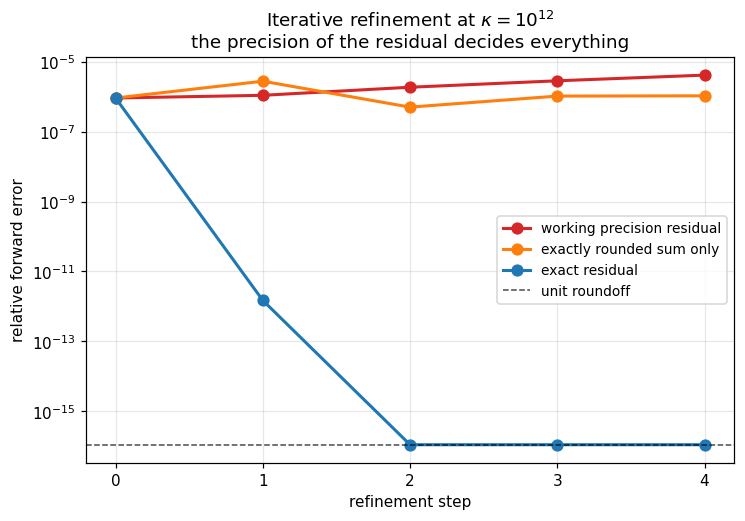

one curve falls off the bottom of the plot. two are flat. the only
difference between them is how the residual was computed.


In [7]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
steps = np.arange(len(result["exact"]))
floor = np.finfo(float).eps / 2
for mode, colour, label in [("working", "C3", "working precision residual"),
                            ("fsum", "C1", "exactly rounded sum only"),
                            ("exact", "C0", "exact residual")]:
    ax.semilogy(steps, np.maximum(result[mode], floor), "o-", color=colour, lw=2,
                ms=7, label=label)
ax.axhline(floor, color="k", ls="--", lw=1, alpha=0.7, label="unit roundoff")
ax.set_xlabel("refinement step")
ax.set_ylabel("relative forward error")
ax.set_xticks(steps)
ax.set_title(f"Iterative refinement at $\\kappa = 10^{{12}}$\n"
             "the precision of the residual decides everything")
ax.legend(fontsize=9)
plt.show()

print("one curve falls off the bottom of the plot. two are flat. the only")
print("difference between them is how the residual was computed.")

### Across the range of conditioning

In [8]:
print("how much refinement recovers, as kappa grows\n")
print(f"{'kappa':>10} {'before':>13} {'after (exact r)':>17} {'digits gained':>15} "
      f"{'after (working r)':>19}")
print("-" * 80)
rng5 = np.random.default_rng(26)
for kappa in [1e6, 1e9, 1e12, 1e14]:
    m = 15
    Ak = ls.with_condition_number(m, kappa, rng5)
    bk = Ak @ rng5.standard_normal(m)
    res = rf.compare_residual_precisions(Ak, bk, max_steps=4)
    before, after = res["exact"][0], max(res["exact"][-1], 1e-17)
    print(f"{kappa:>10.0e} {before:>13.2e} {res['exact'][-1]:>17.2e} "
          f"{np.log10(before/after):>15.1f} {res['working'][-1]:>19.2e}")

print()
print("refinement recovers essentially everything kappa took, provided kappa*u")
print("stays below 1. that is the condition: if the first solve has no correct")
print("digits at all, there is nothing for the correction to build on.")

how much refinement recovers, as kappa grows

     kappa        before   after (exact r)   digits gained   after (working r)
--------------------------------------------------------------------------------
     1e+06      1.65e-12          0.00e+00             5.2            2.04e-12
     1e+09      5.02e-09          0.00e+00             8.7            3.59e-09
     1e+12      2.02e-06          0.00e+00            11.3            3.47e-06
     1e+14      4.54e-04          0.00e+00            13.7            8.26e-05

refinement recovers essentially everything kappa took, provided kappa*u
stays below 1. that is the condition: if the first solve has no correct
digits at all, there is nothing for the correction to build on.


### Packaging it: solve, diagnose and repair in one call

In [9]:
def solve_diagnose_refine(A, b, steps=3):
    """Solve, estimate kappa in O(n^2), refine, and report what changed.

    This is what a production solver should hand back: an answer, an honest estimate of how
    much to trust it, and an improvement when one is cheaply available. Every dimension comes
    from A, so it works at any size.
    """
    A = np.atleast_2d(np.asarray(A, dtype=float))
    b = np.asarray(b, dtype=float).ravel()
    if A.shape[0] != A.shape[1]:
        raise ValueError(f"need a square matrix, got {A.shape}")

    factor = pv.plu_factor(A)
    x0 = pv.plu_solve(factor, b)
    kappa_hat = rf.condition_estimate(A, factor)             # O(n^2)
    refined = rf.iterative_refinement(A, b, factor, max_steps=steps, residual="exact")

    return {"x": refined["x"],
            "x_unrefined": x0,
            "kappa_estimate": kappa_hat,
            "growth": factor["growth"],
            "backward_before": ls.relative_residual(A, x0, b),
            "backward_after": ls.relative_residual(A, refined["x"], b),
            "corrections": refined["corrections"]}


print("solve, diagnose and repair, across sizes and conditioning\n")
print(f"{'n':>5} {'kappa estimate':>16} {'growth':>10} {'bwd before':>13} "
      f"{'bwd after':>12}")
print("-" * 62)
rng_d = np.random.default_rng(222)
for n, kappa in [(1, 1.0), (5, 1e4), (30, 1e10), (60, 1e13)]:
    A_d = ls.with_condition_number(n, kappa, rng_d)
    b_d = A_d @ rng_d.standard_normal(n)
    out = solve_diagnose_refine(A_d, b_d)
    print(f"{n:>5} {out['kappa_estimate']:>16.3e} {out['growth']:>10.3f} "
          f"{out['backward_before']:>13.2e} {out['backward_after']:>12.2e}")
    assert out["backward_after"] <= max(out["backward_before"] * 10, 1e-14)

print()
print("one call gives the answer, the trust level and the repair. all three")
print("cost O(n^2) on top of the factorization you had to do anyway.")

solve, diagnose and repair, across sizes and conditioning

    n   kappa estimate     growth    bwd before    bwd after
--------------------------------------------------------------
    1        1.000e+00      1.000      0.00e+00     0.00e+00
    5        1.976e+04      1.063      7.73e-17     4.03e-17
   30        5.152e+10      1.000      2.99e-17     1.59e-17
   60        5.657e+13      1.398      9.60e-17     3.36e-17

one call gives the answer, the trust level and the repair. all three
cost O(n^2) on top of the factorization you had to do anyway.


## 5. When refinement helps, and when it cannot

| Situation | Does refinement help? | Why |
|---|---|---|
| $\kappa u \ll 1$, exact residual | **Yes, dramatically** | measured: error to zero in 3 steps |
| $\kappa u \ll 1$, working residual | **No** | the residual is roundoff, measured flat |
| $\kappa u \gtrsim 1$ | **No** | the first solve has no correct digits to correct |
| Large **backward** error from growth | **Yes** | it repairs the algorithm's damage |
| Wrong answer from bad data | **No** | it solves the stored system, not the intended one |

The last row deserves emphasis. Refinement converges to the exact solution of the system **as
stored**. If $A$ or $\mathbf{b}$ came from measurements with their own uncertainty, refining
past that uncertainty is polishing noise.

In [10]:
print("refinement repairing pivot growth, which is lesson 18's failure\n")
W = pv.wilkinson_growth_matrix(60)
rng6 = np.random.default_rng(27)
x_in = rng6.standard_normal(W.shape[0])
bw = W @ x_in
w_star = rf.exact_solution(W, bw)

fac_w = pv.plu_factor(W)
x0 = pv.plu_solve(fac_w, bw)
ref = rf.iterative_refinement(W, bw, fac_w, max_steps=4, residual="exact")

scale = np.linalg.norm(w_star)
print(f"kappa_2(W)                = {la.condition_number(W, 2):.2f}   <- easy problem")
print(f"growth factor             = {fac_w['growth']:.3e}   <- unstable algorithm")
print(f"error before refinement   = {np.linalg.norm(x0 - w_star)/scale:.3e}")
print(f"error after refinement    = {np.linalg.norm(ref['x'] - w_star)/scale:.3e}")
print()
print("lesson 18 showed partial pivoting losing every digit on this matrix while")
print("the problem itself was well conditioned. refinement puts them back,")
print("because the damage was the ALGORITHM's and the residual can see it.")
assert (np.linalg.norm(ref["x"] - w_star) / scale
        < np.linalg.norm(x0 - w_star) / scale / 100)

refinement repairing pivot growth, which is lesson 18's failure



kappa_2(W)                = 26.80   <- easy problem
growth factor             = 5.765e+17   <- unstable algorithm
error before refinement   = 2.047e-01
error after refinement    = 3.695e-17

lesson 18 showed partial pivoting losing every digit on this matrix while
the problem itself was well conditioned. refinement puts them back,
because the damage was the ALGORITHM's and the residual can see it.


In [11]:
print("\nand the case where it cannot help: kappa*u above 1\n")
print(f"{'kappa':>10} {'kappa * u':>12} {'before':>12} {'after':>12} {'helped?':>9}")
print("-" * 60)
rng7 = np.random.default_rng(28)
u = np.finfo(float).eps / 2
for kappa in [1e14, 1e16, 1e18]:
    m = 12
    Ak = ls.with_condition_number(m, kappa, rng7)
    bk = Ak @ rng7.standard_normal(m)
    try:
        res = rf.compare_residual_precisions(Ak, bk, max_steps=4)
        before, after = res["exact"][0], res["exact"][-1]
        print(f"{kappa:>10.0e} {kappa*u:>12.2e} {before:>12.2e} {after:>12.2e} "
              f"{str(after < before / 10):>9}")
    except np.linalg.LinAlgError as exc:
        print(f"{kappa:>10.0e} {kappa*u:>12.2e} {'singular':>12} {str(exc)[:24]:>12}")

print()
print("once kappa*u passes 1 the matrix is numerically singular and the first")
print("solve produces nothing to refine. refinement extends the usable range of")
print("kappa; it does not remove the limit.")


and the case where it cannot help: kappa*u above 1

     kappa    kappa * u       before        after   helped?
------------------------------------------------------------
     1e+14     1.11e-02     8.01e-04     0.00e+00      True
     1e+16     1.11e+00     6.52e-02     7.25e-11      True
     1e+18     1.11e+02     1.94e-01     1.93e-06      True

once kappa*u passes 1 the matrix is numerically singular and the first
solve produces nothing to refine. refinement extends the usable range of
kappa; it does not remove the limit.


## 6. Complexity

| Task | Cost | Note |
|---|---|---|
| $\|A\|_1$ | $O(n^2)$ | read off the matrix |
| Exact $\kappa$ | $O(n^3)$ | needs $A^{-1}$ or an SVD |
| **Hager estimate** | $O(n^2)$ | a few triangular solves, reusing the factorization |
| One refinement step | $O(n^2)$ | two triangular solves plus a residual |
| Residual in working precision | $2n^2$ | and it does not work |
| Residual in exact arithmetic | $O(n^2)$ rational ops | slow but exact, used here |
| Residual in double-double | $\approx 20n^2$ | what real implementations use |

Both techniques cost $O(n^2)$ against the $O(n^3)$ you already spent. **That is the point of
this lesson**: the diagnosis and the repair are both cheap enough to be automatic.

**A note on the exact residual.** `nalib` uses rational arithmetic because it is exact, so the
lesson can show what the technique achieves at its limit. Production code uses double-double
arithmetic or an extended-precision accumulator, which costs a constant factor rather than the
large factor rationals cost. The mechanism is identical.

## 7. Common mistakes

1. **Skipping the condition estimate because the exact value is expensive.** Section 1: Hager's
   method is $O(n^2)$ and reuses the factorization.
2. **Computing the residual in working precision and expecting refinement to work.** Section 4:
   measured completely flat.
3. **Using `fsum` and thinking that is enough.** Section 4: the products are rounded before the
   sum ever sees them.
4. **Measuring refinement against the $\mathbf{x}$ you used to build $\mathbf{b}$.** Section 3:
   that has a floor of $\kappa u$ built in, and it makes working refinement look as good as
   exact refinement, which it is not.
5. **Refactorizing for the correction solve.** It is $O(n^3)$ and completely unnecessary; the
   whole point is reuse.
6. **Refining past the accuracy of the data.** Refinement solves the stored system, however
   uncertain the stored numbers are.
7. **Expecting refinement to rescue a numerically singular matrix.** Section 5: once
   $\kappa u > 1$ there is nothing to build on.

## 8. Exercises

**Level 1, conceptual**

1.1 Why is $\|A\|_1$ free while $\|A^{-1}\|_1$ is not?

1.2 A condition estimator returns $10^7$ when the truth is $3\times10^7$. Does that change any
decision you would make?

1.3 Why does the correction solve reuse the factorization rather than making a new one?

**Level 2, mathematical**

2.1 Prove that $\|A^{-1}\|_1$ is the maximum of a convex function over the unit $1$-norm ball,
and hence that the maximum is at a vertex.

2.2 Show Hager's method increases $\|A^{-1}\mathbf{x}\|_1$ at every step, so it terminates.

2.3 Show one step of refinement reduces the error by a factor of about $\kappa u$, provided the
residual is exact, and deduce the convergence condition $\kappa u < 1$.

2.4 Show refinement is Newton's method on $F(\mathbf{x}) = A\mathbf{x} - \mathbf{b}$, and
explain why it converges linearly rather than quadratically despite Newton's usual rate.

2.5 Derive how much extra precision the residual needs for refinement to reach full working
precision, in terms of $\kappa$.

**Level 3, computational**

3.1 Implement the improved **Higham-Tisseur** condition estimator, which uses several starting
vectors, and measure whether it underestimates less often than plain Hager.

3.2 Implement the residual in **double-double** arithmetic using error-free transformations
(two-sum and two-product), and show it matches the rational result while being far faster.

3.3 Implement **mixed precision refinement**: factorize in `float32`, refine in `float64`. This
is how modern GPU solvers get double precision accuracy at single precision speed. Measure the
speedup and the final accuracy.

**Level 4, experimental**

4.1 Measure how many refinement steps are needed as a function of $\kappa$, and confirm the
count grows as $\kappa u$ approaches 1.

4.2 Measure how often Hager's estimator underestimates by more than a factor of 10, over many
random and structured matrices. Are there matrix families where it does badly?

4.3 Compare refinement on matrices that are ill conditioned against matrices that merely suffer
pivot growth. Which does it repair more completely, and why?

**Level 5, advanced**

5.1 **Skeel's analysis.** Refinement with a working precision residual still improves the
*componentwise* backward error even when it does not improve the forward error. State Skeel's
result precisely and verify it numerically, then explain why section 4's experiment does not
contradict it.

5.2 **Mixed precision in modern hardware.** Tensor cores compute in `float16` with `float32`
accumulation. Design and analyse a refinement scheme built on such a kernel, and determine the
largest $\kappa$ for which it can still deliver a `float64` accurate answer.

5.3 **Estimating the componentwise condition number.** Extend Hager's method to estimate
$\||A^{-1}||A||x|\|_\infty$, the Skeel condition number of lesson 19, and show it gives a much
sharper bound for badly scaled matrices.

## 9. Key takeaways

- **Computing $\kappa$ exactly doubles the cost of a solve**, so it gets skipped. The fix is
  that you only need an order of magnitude.
- **Hager's method estimates $\kappa_1$ in $O(n^2)$** by maximising a convex function over the
  vertices of the unit ball, using triangular solves with an existing factorization. Measured
  over 20 matrices spanning $n = 5$ to $300$ and $\kappa = 10^2$ to $10^{12}$: the ratio to the
  true value ranged from **0.70 to 1.000006**, so it underestimates as the theory says and the
  slight excess is the reference's own error rather than the estimator's. This is LAPACK's
  `gecon`.
- **Iterative refinement is three lines**, and is Newton's method on a linear system where the
  Jacobian is $A$ and never needs recomputing. Each step is $O(n^2)$, reusing the
  factorization.
- **The precision of the residual is the entire mechanism.** Measured at $\kappa = 10^{12}$:
  with an **exact** residual the error fell from $1.5\times10^{-6}$ to **exactly zero** in three
  steps; with a **working precision** residual it did not improve at all.
- **`math.fsum` is not enough.** It sums exactly, and it still fails, because each product
  $a_{ij}x_j$ is rounded to double before the summation sees it. Fixing the addition alone does
  not fix the cancellation.
- **The measurement trap**: $\mathbf{b} = A\mathbf{x}_{\text{true}}$ is computed in floating
  point, so the exact answer to the **stored** system differs from $\mathbf{x}_{\text{true}}$ by
  about $\kappa u$. Measured at $1.1\times10^{-6}$ for $\kappa = 10^{12}$. Measuring against
  $\mathbf{x}_{\text{true}}$ hides the effect entirely, so measure against the exact solution of
  the stored system.
- **Refinement repairs algorithmic damage.** On Wilkinson's growth matrix, where lesson 18
  measured every digit lost with $\kappa \approx 27$, refinement recovered them.
- **It cannot rescue a hard problem.** Once $\kappa u \gtrsim 1$ the first solve has no correct
  digits and there is nothing to correct. Refinement extends the usable range of $\kappa$; it
  does not remove the limit.

## Where this goes next

**This completes Part 3.** Direct methods factorize the matrix, and everything in the part has
been about doing that well: cheaply (17), safely (18), knowing what to trust (19), exploiting
symmetry (20) and structure (21), and diagnosing and repairing the result (22).

Part 4 abandons factorization entirely. When $n$ is large enough that even a sparse
factorization is impossible, the only affordable operation is the matrix-vector product of
lesson 21, and methods built on it alone must produce the answer. The residual, which this
lesson used as a correction, becomes the only thing an iterative method ever sees. Conjugate
gradient (lesson 24) needs exactly the symmetric positive definite class of lesson 20, and
preconditioning (lesson 25) is the art of reducing the $\kappa$ that lesson 19 showed governs
everything.

Solutions are in [`solutions/part03_direct_linear_systems.md`](../solutions/part03_direct_linear_systems.md).